# importing libraries 

In [25]:
import pandas as pd
import os
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import LinearSVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.metrics import classification_report

# importing data

In [26]:
print(os.getcwd())
filepath = os.path.join(os.path.dirname(os.getcwd()), 'data/dataset/processed/go_emotion_dutch.csv')

c:\Users\koenm\Documents\repositorys\year_2\fae2-nlpr-group-group-4-1\fae2-nlpr-group-group-4-1\nlp_cia\task 6


In [27]:
df_train = pd.read_csv(filepath)
df_train = df_train.sample(n=len(df_train))

In [28]:
filepath_2 = os.path.join(os.path.dirname(os.getcwd()), "data/group_4_url_1_transcript.csv")
df_test = pd.read_csv(filepath_2)
df_test = df_test.sample(n=len(df_test))

# training model

In [29]:
# Train on df_train
vectorizer = TfidfVectorizer(
    max_features=7000,        # Keep top N most frequent words
    ngram_range=(1, 2),       # (1,1) = unigrams, (1,2) = uni+bigrams
    min_df=2,                 # Ignore words appearing in < 2 documents
    max_df=0.95,              # Ignore words appearing in > 95% of docs
    sublinear_tf=True,        # Apply log scaling to term frequency
    use_idf=True,             # Use inverse document frequency
    norm='l2'                 # Normalize vectors to unit length
)
X_train_tfidf = vectorizer.fit_transform(df_train['Sentence'])
model = LinearSVC(class_weight='balanced', max_iter=1000, C=0.1, loss='squared_hinge').fit(X_train_tfidf, df_train['Emotion_core'])


# Test on df_test
X_test_tfidf = vectorizer.transform(df_test['Sentence'])
predictions = model.predict(X_test_tfidf)

# Calculate metrics
accuracy = accuracy_score(df_test['Emotion_core'], predictions)
precision = precision_score(df_test['Emotion_core'], predictions, average='weighted')
recall = recall_score(df_test['Emotion_core'], predictions, average='weighted')
f1 = f1_score(df_test['Emotion_core'], predictions, average='weighted')

print(f"Accuracy:  {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall:    {recall:.3f}")
print(f"F1-score:  {f1:.3f}")
print(classification_report(df_test['Emotion_core'], predictions))

Accuracy:  0.508
Precision: 0.499
Recall:    0.508
F1-score:  0.500
              precision    recall  f1-score   support

       anger       0.11      0.11      0.11        37
     disgust       0.04      0.06      0.04        17
        fear       0.13      0.04      0.06        56
   happiness       0.50      0.46      0.48       198
     neutral       0.64      0.68      0.66       546
     sadness       0.45      0.35      0.39       104
    surprise       0.21      0.27      0.24        92

    accuracy                           0.51      1050
   macro avg       0.30      0.28      0.28      1050
weighted avg       0.50      0.51      0.50      1050



# hyper parameter tuning

In [30]:
# Create vectorizer with hyperparameters
vectorizer = TfidfVectorizer()

# Set up parameter grid
param_grid = {
    'C': [0.1, 1, 10, 100],  # Regularization strength
    'loss': ['hinge', 'squared_hinge'],  # Loss function
    'max_iter': [1000, 2000, 3000],
    'class_weight': ['balanced', None]
}

# Create base model
svm_model = LinearSVC()

# Grid search with cross-validation
X_train_tfidf = vectorizer.fit_transform(df_train['Sentence'])
grid_search = GridSearchCV(
    svm_model, 
    param_grid, 
    cv=3,  # 3-fold cross-validation
    scoring='f1_weighted',
    verbose=1,
    n_jobs=-1  # Use all CPU cores
)

# Fit grid search
grid_search.fit(X_train_tfidf, df_train['Emotion_core'])

# Best parameters
print("Best parameters:", grid_search.best_params_)
print(f"Best CV score: {grid_search.best_score_:.3f}")

# Test with best model
X_test_tfidf = vectorizer.transform(df_test['Sentence'])
predictions = grid_search.predict(X_test_tfidf)

# Calculate metrics
accuracy = accuracy_score(df_test['Emotion_core'], predictions)
print(f"\nTest Accuracy: {accuracy:.3f}")

Fitting 3 folds for each of 48 candidates, totalling 144 fits
Best parameters: {'C': 0.1, 'class_weight': 'balanced', 'loss': 'squared_hinge', 'max_iter': 1000}
Best CV score: 0.510

Test Accuracy: 0.507


# error analysis

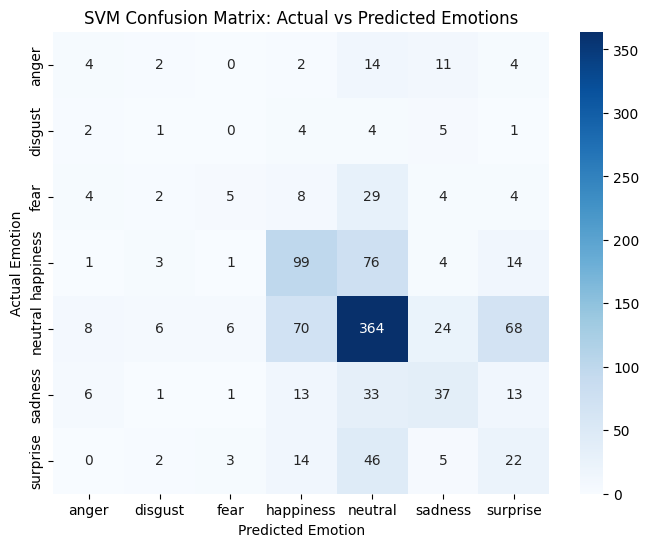


Prediction Distribution:
neutral      566
happiness    210
surprise     126
sadness       90
anger         25
disgust       17
fear          16
Name: count, dtype: int64

Actual Distribution:
Emotion_core
neutral      546
happiness    198
sadness      104
surprise      92
fear          56
anger         37
disgust       17
Name: count, dtype: int64


In [31]:
# Create confusion matrix
cm = confusion_matrix(df_test['Emotion_core'], predictions)
emotions = sorted(df_test['Emotion_core'].unique())

# Visualize
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=emotions, yticklabels=emotions)
plt.title('SVM Confusion Matrix: Actual vs Predicted Emotions')
plt.ylabel('Actual Emotion')
plt.xlabel('Predicted Emotion')
plt.show()

# Show prediction distribution
print("\nPrediction Distribution:")
print(pd.Series(predictions).value_counts())
print("\nActual Distribution:")
print(df_test['Emotion_core'].value_counts())